In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from multicam.multicam import MultiCAM, MultiCamSampling
from multicam.qt import qt, qt_gauss
from multicam_tng.multicam2 import multicam_new_prediction_repeats
from scipy.stats import spearmanr

from multicam_tng.utils import get_an_from_mpeak_mah, generate_randoms
from astropy.table import Table


TNG_H = 0.6774
COLOR_CUT = 1.0  # Changed a little bit


from halotools.mock_observables import return_xyz_formatted_array, tpcf_jackknife, tpcf


In [5]:
# this is just metadata which sims share
metadata = pd.read_csv("../../data/tng300-1-table.csv")
redshift_snaps = metadata["Redshift"].values
scales = 1 / (1 + redshift_snaps)
scales.shape

(100,)

In [ ]:
# load data
_hydro_raw = Table.read("../../data/hydro_final.ecsv")
flag = _hydro_raw["SubhaloFlag"]
hydro_raw = _hydro_raw[flag == 1]
len(hydro_raw)

101431

In [7]:
# Add z12
hydro_raw["z12"] = (1 / hydro_raw["a12"]) - 1

In [8]:
# apply lower cut on mpeak (resolution) only and use this catalog for SHAM application
log_mpeak = np.log10(hydro_raw["mpeak"])
mpeak_cut_mask = log_mpeak > 11
hydro_high = hydro_raw[mpeak_cut_mask]
len(hydro_high)

12659

In [9]:
# sham application
x = np.log10(hydro_high["mpeak"].data)
y = np.log10(hydro_high["stellar_mass"].data)
logmstar_sham_high = qt(x, y)
logmstar_sham_high.shape

(12659,)

In [10]:
x1 = np.log10(hydro_raw["stellar_mass"])
x2 = np.log10(hydro_raw["mpeak"])
star_mask = (x1 > 9.5) & (x1 < 10.2) & (x2 > 11)
hydro_mstar_cut = hydro_raw[star_mask]

# get sham stellar mass bin predicted catalog
sham_mask = (logmstar_sham_high > 9.5) & (logmstar_sham_high < 10.2)
hydro_sham = hydro_high[sham_mask]


len(hydro_mstar_cut), len(hydro_sham)

(4051, 4051)

In [11]:
# CAM prediction for color
color_cam_pred = qt(hydro_sham["z12"].data, hydro_mstar_cut["color"])
color_cam_pred.shape

(4051,)

In [71]:
# ns = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
ns = np.linspace(0, 1, 21)[1:-1]  # want to avoid 0, 1 edge cases
# ns = np.array([0.5])
ns

array([0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55,
       0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95])

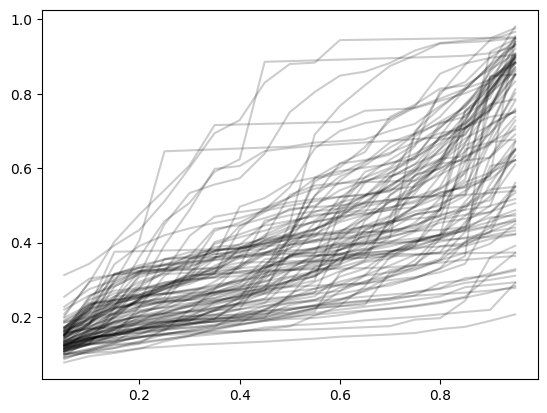

In [72]:
# example
an = get_an_from_mpeak_mah(hydro_raw["mpeak_mah"].data, scales=scales, ns=ns)

idx = np.random.randint(an.shape[0], size=(100,))
for ii in idx:
    plt.plot(ns, an[ii], c="k", alpha=0.2)

In [73]:
# NOTE: can only train multicam on mpeak mass bin
_x = np.log10(hydro_raw["mpeak"])
mask = (_x > 11) & (_x < 12)
hydro_mpeak = hydro_raw[mask]

x_train = get_an_from_mpeak_mah(hydro_mpeak["mpeak_mah"], scales=scales, ns=ns)
y_train = hydro_mpeak["color"].reshape(-1, 1)

# but we want to apply on SHAM bin
x_test = get_an_from_mpeak_mah(hydro_sham["mpeak_mah"], scales=scales, ns=ns)

# and reproduce the color distribution in the true stellar mass bin!
y_true = hydro_mstar_cut["color"].reshape(-1, 1)

color_multicam_pred = multicam_new_prediction_repeats(
    x_test, x_train=x_train, y_train=y_train, y_true=y_true
)[:, 0]
color_multicam_pred.shape

(4051,)

(array([  0.,   0.,   0.,   1.,   2.,   4.,   5.,  18.,  27.,  49.,  82.,
        133., 194., 260., 301., 338., 315., 287., 250., 202., 180., 152.,
        123., 106.,  70.,  69.,  84., 129., 201., 252., 143.,  54.,  18.,
          2.,   0.,   0.,   0.,   0.,   0.,   0.]),
 array([0.2   , 0.2325, 0.265 , 0.2975, 0.33  , 0.3625, 0.395 , 0.4275,
        0.46  , 0.4925, 0.525 , 0.5575, 0.59  , 0.6225, 0.655 , 0.6875,
        0.72  , 0.7525, 0.785 , 0.8175, 0.85  , 0.8825, 0.915 , 0.9475,
        0.98  , 1.0125, 1.045 , 1.0775, 1.11  , 1.1425, 1.175 , 1.2075,
        1.24  , 1.2725, 1.305 , 1.3375, 1.37  , 1.4025, 1.435 , 1.4675,
        1.5   ]),
 [<matplotlib.patches.Polygon at 0x11ca64190>])

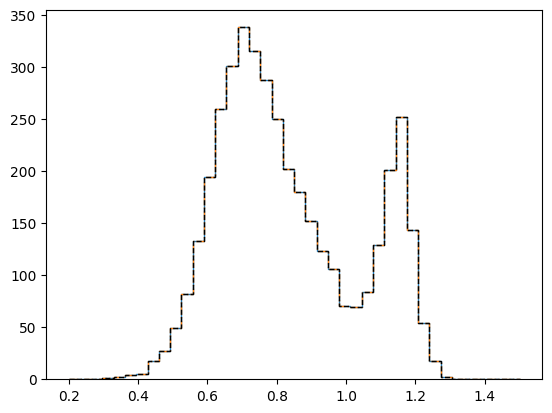

In [74]:
bins = np.linspace(0.2, 1.5, 41)


plt.hist(hydro_mstar_cut["color"], bins=bins, histtype="step", ls="-")
plt.hist(color_cam_pred, bins=bins, histtype="step", ls="-.")
plt.hist(color_multicam_pred, bins=bins, histtype="step", ls="--", color="k")

In [75]:
spearmanr(hydro_mstar_cut["color"], hydro_mstar_cut["a12"])

SignificanceResult(statistic=np.float64(-0.5831175609386711), pvalue=np.float64(0.0))

In [ ]:
(
    spearmanr(color_cam_pred, color_multicam_pred),
    spearmanr(
        hydro_sham["color"],
    ),
    spearmanr(hydro_sham["color"], color_multicam_pred),
)

(SignificanceResult(statistic=np.float64(0.870128792037689), pvalue=np.float64(0.0)),
 SignificanceResult(statistic=np.float64(0.6376297195146369), pvalue=np.float64(0.0)),
 SignificanceResult(statistic=np.float64(0.7117311000419345), pvalue=np.float64(0.0)))

## Clustering

In [77]:
Lbox = 110.7 * TNG_H  # TNG box size in Mpc /h
rbins = np.logspace(np.log10(0.1), np.log10(24.9), 16)
rbin_centers = 0.5 * (rbins[1:] + rbins[:-1])
randoms = generate_randoms(lbox=Lbox, n_randoms=50_000, rng=41)

randoms.shape

(50000, 3)

In [38]:
true_color = hydro_mstar_cut["color"]
red_true = hydro_mstar_cut[true_color > COLOR_CUT]
blue_true = hydro_mstar_cut[true_color <= COLOR_CUT]


red_pred = hydro_sham[color_cam_pred > COLOR_CUT]
blue_pred = hydro_sham[color_cam_pred <= COLOR_CUT]

multicam_red_pred = hydro_sham[color_multicam_pred > COLOR_CUT]
multicam_blue_pred = hydro_sham[color_multicam_pred <= COLOR_CUT]

In [39]:
(
    len(red_pred),
    len(red_true),
    len(multicam_red_pred),
    len(blue_true),
    len(blue_pred),
    len(multicam_blue_pred),
)

(981, 981, 981, 3070, 3070, 3070)

In [40]:
xyz_red = return_xyz_formatted_array(
    red_true["x"].data, red_true["y"].data, red_true["z"].data
)
xyz_blue = return_xyz_formatted_array(
    blue_true["x"].data, blue_true["y"].data, blue_true["z"].data
)


xi_red_true = tpcf(xyz_red, rbins, randoms=randoms, period=Lbox, num_threads="max")

xi_blue_true = tpcf(xyz_blue, rbins, randoms=randoms, period=Lbox, num_threads="max")


In [41]:
xyz_red = return_xyz_formatted_array(
    red_pred["x"].data, red_pred["y"].data, red_pred["z"].data
)
xyz_blue = return_xyz_formatted_array(
    blue_pred["x"].data, blue_pred["y"].data, blue_pred["z"].data
)


xi_red_cam = tpcf(xyz_red, rbins, randoms=randoms, period=Lbox, num_threads="max")

xi_blue_cam = tpcf(xyz_blue, rbins, randoms=randoms, period=Lbox, num_threads="max")


In [42]:
xyz_red = return_xyz_formatted_array(
    multicam_red_pred["x"].data,
    multicam_red_pred["y"].data,
    multicam_red_pred["z"].data,
)
xyz_blue = return_xyz_formatted_array(
    multicam_blue_pred["x"].data,
    multicam_blue_pred["y"].data,
    multicam_blue_pred["z"].data,
)


xi_red_multicam = tpcf(xyz_red, rbins, randoms=randoms, period=Lbox, num_threads="max")

xi_blue_multicam = tpcf(
    xyz_blue, rbins, randoms=randoms, period=Lbox, num_threads="max"
)


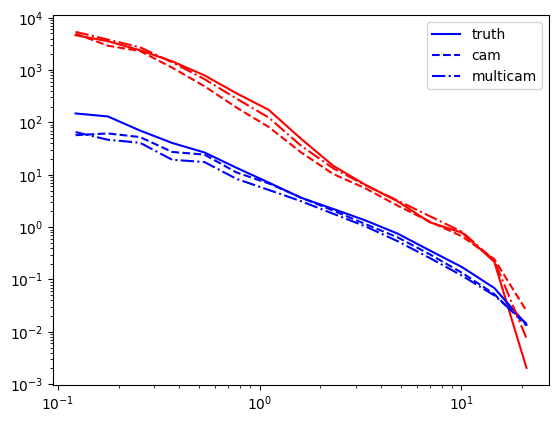

In [43]:
plt.loglog(rbin_centers, xi_red_true, c="r")
plt.loglog(rbin_centers, xi_blue_true, c="b", label="truth")


plt.loglog(rbin_centers, xi_red_cam, c="r", ls="--")
plt.loglog(rbin_centers, xi_blue_cam, c="b", ls="--", label="cam")

plt.loglog(rbin_centers, xi_red_multicam, c="r", ls="-.")
plt.loglog(rbin_centers, xi_blue_multicam, c="b", ls="-.", label="multicam")

plt.legend()

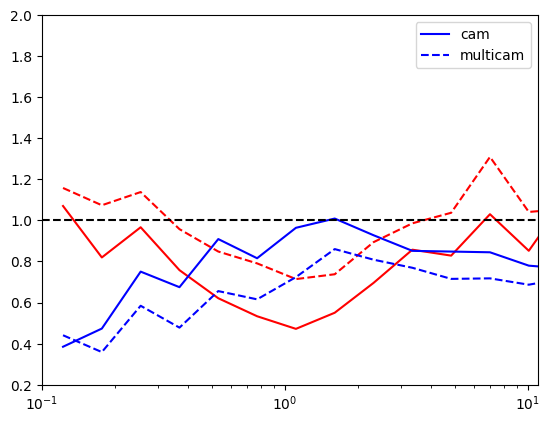

In [44]:
plt.semilogx(rbin_centers, xi_red_cam / xi_red_true, c="r", ls="-")
plt.semilogx(rbin_centers, xi_blue_cam / xi_blue_true, c="b", ls="-", label="cam")

plt.semilogx(rbin_centers, xi_red_multicam / xi_red_true, c="r", ls="--")
plt.semilogx(
    rbin_centers, xi_blue_multicam / xi_blue_true, c="b", ls="--", label="multicam"
)

plt.axhline(1.0, ls="--", c="k")

plt.xlim(0.1, 11)
plt.ylim(0.2, 2.0)

plt.legend()

# i think this reproduces haley's results
# doesn't seem to get much affected by adding scatter or not...
# NOTE: double check, but mpeak mass bin cut at the beginning does not seem to affect output